# Updating Conjugate Priors

A modern, offline beta-binomial example for updating directional market beliefs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bayesian_utils import ensure_output_dir, simulate_strategy_returns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()
from bayesian_utils import beta_binomial_updates


In [2]:
returns = simulate_strategy_returns(periods=252, seed=101)['market']
observations = (returns > 0).astype(int)
posterior = beta_binomial_updates(observations, alpha=10, beta=10)
posterior.tail()

,step,observation,alpha,beta,posterior_mean,posterior_std
247,248,1,133.0000,135.0000,0.4963,0.0305
248,249,1,134.0000,135.0000,0.4981,0.0304
249,250,1,135.0000,135.0000,0.5000,0.0304
250,251,1,136.0000,135.0000,0.5018,0.0303
251,252,1,137.0000,135.0000,0.5037,0.0303


In [3]:
summary = posterior.iloc[-1].to_frame('value')
summary.to_csv(OUTPUT / 'conjugate_prior_final.csv')
posterior.to_parquet(OUTPUT / 'conjugate_prior_updates.parquet')
summary

,value
step,252.0000
observation,1.0000
alpha,137.0000
beta,135.0000
posterior_mean,0.5037
posterior_std,0.0303


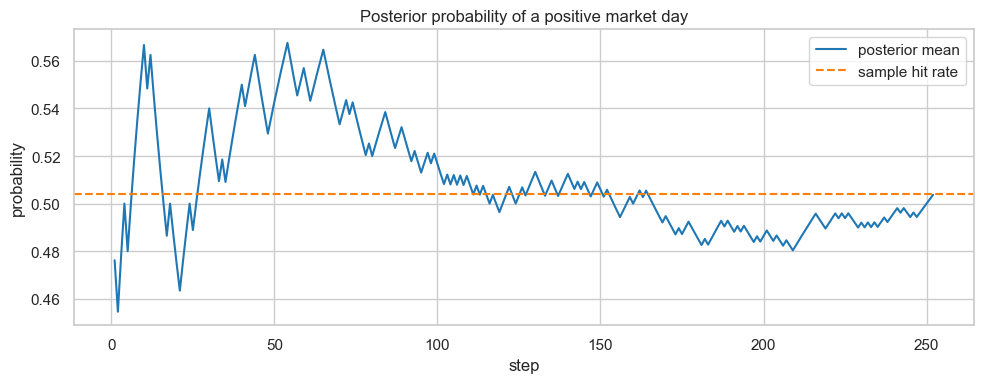

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
posterior.set_index('step')['posterior_mean'].plot(ax=ax, color='tab:blue', label='posterior mean')
ax.axhline(observations.mean(), color='tab:orange', linestyle='--', label='sample hit rate')
ax.set(title='Posterior probability of a positive market day', ylabel='probability')
ax.legend()
plt.tight_layout()